# 06 · Candidatos y decisión

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


## Comparar sobre la misma validación
El bosque no tiene garantizado mejorar. Este notebook muestra resultados; implementar el gate es parte de la actividad.

In [2]:
from time import perf_counter
results={}; fitted={}; probabilities={}; fit_seconds={}
for kind in ["baseline","candidate"]:
    started=perf_counter()
    estimator=pipeline(kind)
    estimator.fit(train[FEATURES],(train.y=="yes").astype(int))
    fit_seconds[kind]=perf_counter()-started
    fitted[kind]=estimator
    probabilities[kind]=estimator.predict_proba(validation[FEATURES])[:,1]
    results[kind]=metrics((validation.y=="yes").astype(int),probabilities[kind])
display(pd.DataFrame(results).T[["average_precision","recall","brier","roc_auc"]])

,average_precision,recall,brier,roc_auc
baseline,0.168429,0.0,0.104156,0.624764
candidate,0.155108,0.0,0.106439,0.585485


## Política
AP no cae más de 0.005, recall no más de 0.02 y Brier no sube más de 0.01. Elegibilidad no sustituye revisión de equidad, latencia y contexto.

In [3]:
b=results["baseline"];c=results["candidate"]
display(pd.DataFrame({"metrica":["AP","Recall","Brier"],"cambio":[c["average_precision"]-b["average_precision"],c["recall"]-b["recall"],c["brier"]-b["brier"]]}))

,metrica,cambio
0,AP,-0.013321
1,Recall,0.000000
2,Brier,0.002283


## Ensayo de recuperación
Completar gate, seguir laboratorio de réplica y rollback, comprobar versión HTTP tras reinicio. El notebook no cambia el modelo activo.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Comparación pareada con bootstrap exploratorio
Reutilizamos las probabilidades ya calculadas de ambos modelos sobre las mismas filas de validation. Muestreamos índices comunes para preservar la relación entre sus errores. Las 200 remuestras equilibran tiempo local y demostración; no constituyen certificación de mejora. El remuestreo por filas supone independencia aproximada, no verificable completamente por persona o tiempo en este dataset.

,delta_AP,delta_Brier
cuantil,,
0.025,-0.027345,0.001803
0.500,-0.012669,0.002257
0.975,-0.003006,0.002790


{'remuestras_validas': 200, 'remuestras_una_clase': 0}


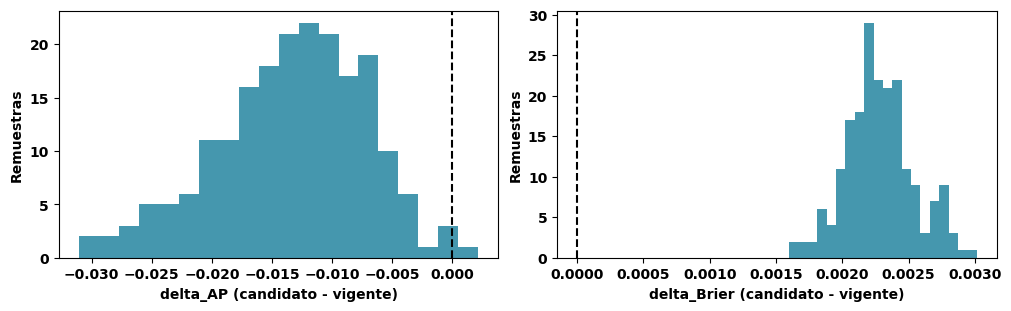

In [4]:
from sklearn.metrics import average_precision_score,brier_score_loss
truth=(validation.y=="yes").astype(int).to_numpy()
p_baseline=probabilities["baseline"];p_candidate=probabilities["candidate"]
rng=np.random.default_rng(SEED);bootstrap=[];skipped=0
for _ in range(200):
    idx=rng.integers(0,len(truth),len(truth));y=truth[idx]
    if len(np.unique(y))<2:
        skipped+=1;continue
    bootstrap.append({"delta_AP":average_precision_score(y,p_candidate[idx])-average_precision_score(y,p_baseline[idx]),
                      "delta_Brier":brier_score_loss(y,p_candidate[idx])-brier_score_loss(y,p_baseline[idx])})
draws=pd.DataFrame(bootstrap)
assert len(draws)+skipped==200
display(draws.quantile([.025,.5,.975]).rename_axis("cuantil"))
print({"remuestras_validas":len(draws),"remuestras_una_clase":skipped})
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(10,3),constrained_layout=True)
for ax,column in zip(axes,["delta_AP","delta_Brier"]):
    ax.hist(draws[column],bins=20,color="#167d9a",alpha=.8)
    ax.axvline(0,color="black",linestyle="--")
    ax.set(xlabel=column+" (candidato - vigente)",ylabel="Remuestras")
plt.show()

**Interpretación:** para AP, una diferencia positiva favorece al candidato; para Brier, una negativa. Un intervalo que cruza cero no prueba equivalencia. Una diferencia favorable no sustituye revisión de umbral, capacidad, grupos y compatibilidad. El gate obligatorio conserva sus tolerancias y debe implementarlo el equipo; este notebook no promueve ni escribe current.json.

### Costo de ajuste y tamaño serializado
Medimos tiempos observados de las ejecuciones de este notebook y serializamos cada pipeline en memoria. El tamaño de bytes no equivale a memoria residente en producción. Los tiempos dependen de máquina y carga; se conserva su carácter de observación local.

In [5]:
import io,joblib
cost=[]
for name,estimator in fitted.items():
    stream=io.BytesIO();joblib.dump(estimator,stream)
    cost.append({"modelo":name,"segundos_ajuste":fit_seconds[name],"bytes_joblib":stream.getbuffer().nbytes,
                 "AP_validation":results[name]["average_precision"],"Brier_validation":results[name]["brier"]})
display(pd.DataFrame(cost))
assert all(row["bytes_joblib"]>0 and row["segundos_ajuste"]>0 for row in cost)

,modelo,segundos_ajuste,bytes_joblib,AP_validation,Brier_validation
0,baseline,0.161781,6657,0.168429,0.104156
1,candidate,1.744512,3820802,0.155108,0.106439


**Decisión escrita:** complete cuatro frases: el candidato cambia…, la evidencia sobre validation indica…, todavía no sabemos…, por tanto proponemos…. Mantener el baseline puede ser una decisión correcta. Para ensayar promoción y rollback se utiliza una réplica equivalente después de completar A3-01 y A3-02, sin presentar esa réplica como mejora predictiva.